In [7]:
import numpy as np, matplotlib.pyplot as plt, time
from astropy.table import Table
from pathlib import Path

# Import nuGundam related classes
from nugundam import (pcf, proj_auto_counts, plot_result2d,
    ProjectedAutoConfig, ProjectedAutoCountsConfig,
    ProjectedBinning, ProjectedGridSpec, ProjectedCatalogColumns,
    WeightSpec, BootstrapSpec, DistanceSpec)

# 2D correlations with nuGundam
-----------------
This notebook is a quick tutorial of how to calculate and plot 2D correlation functions and 2D counts in nuGundam

## Read and prepare data

In [8]:
# Adjust BASEPATH if needed
BASEPATH = Path('./data/')
DATAFILE = BASEPATH / 'DR7-lrg-d4000.fits'
RANDFILE = BASEPATH / 'DR7-lrg-rand.fits'

data = Table.read(DATAFILE)
rans = Table.read(RANDFILE)

## 1. Create configuration

First we need to create a configuration object which is designed to hold several specifications of the computation to perform. In this case it corresponds to an angular auto-correlation so we use a config object of type ``ProjectedAutoConfig``. This is where you specify the estimator chosen, the binning for counting, the counting grid, the name of relevant columns in the datasets, and various other parameters.

In [9]:
config1 = ProjectedAutoConfig(
    # Choose estimator > NAT, DP, LS
    estimator = "LS",
    # Select dataset columns
    columns_data=ProjectedCatalogColumns(ra="ra", dec="dec", redshift='z'),
    columns_random=ProjectedCatalogColumns(ra="ra", dec="dec", redshift='z'),
    # Set number of threads
    nthreads = 4,
    # Specify binning in rp-direction > number_of_bins, minimum separation [Mpc/h], bin size (in dex if logsep=True)
    # Specify binning in pi-direction > number_of_bins, bin size
    binning=ProjectedBinning.from_binsize(
        nsepp=78, seppmin=0.01, dsepp=0.5, logsepp=False,
        nsepv=60, dsepv=0.5),
    # Choose counting grid and ordering 
    grid = ProjectedGridSpec(autogrid=True, pxorder="natural"),
    # Choose weight model > "auto", "weighted", "unweighted"
    weights = WeightSpec(weight_mode="unweighted"),
    # Enable boostrap error module
    bootstrap = BootstrapSpec(enabled=True, nbts=50, bseed=12345),
    # Enable distance calculation module
    distance=DistanceSpec(calcdist=True, h0=100., omegam=0.25, omegal=0.75)
)

## 2. Run correlation

In [10]:
ti = time.time()
result1 = pcf(data, rans, config1)
print(f'elapsed time [s]: {time.time()-ti:.3f}')

[pcf] preparing data and randoms
[pcf] counting DD / RR / DR with estimator=LS


[pcf] estimating correlation
[pcf] done
elapsed time [s]: 2.310


## 3. Plot Xi(rp,pi)

With the configuration above you have calculated the 2D counts in a 78x60 rp-pi grid. nuGundam has plotting routines to show the 2D Xi(rp,pi) correlation

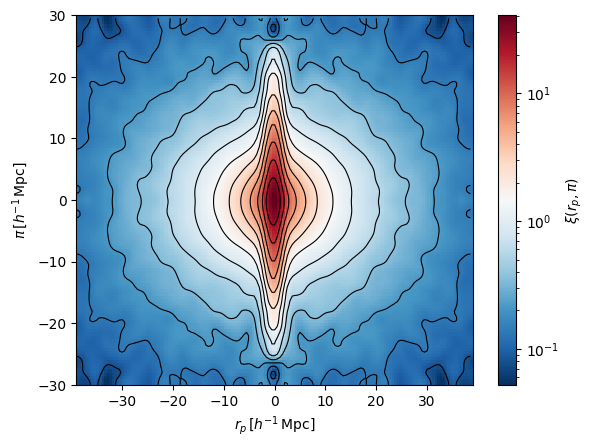

In [11]:
result1.plot2d(which="xi", contours=True, color_scale="log-positive", smoothing=2);

<Axes: xlabel='$r_p\\,[h^{-1}\\,\\mathrm{Mpc}]$', ylabel='$\\pi\\,[h^{-1}\\,\\mathrm{Mpc}]$'>

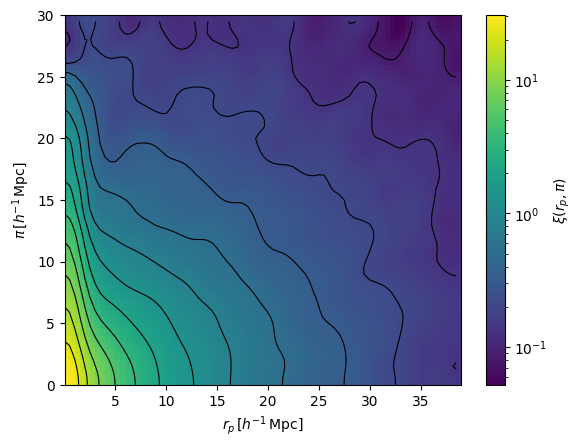

In [12]:
result1.plot2d(which="xi", contours=True, color_scale="log-positive", cmap='viridis', 
               smoothing=2, mirror='none')

## 4. Compute DD counts in (rp,pi) and plot

In [13]:
config2 = ProjectedAutoCountsConfig(
    columns=ProjectedCatalogColumns(ra="ra", dec="dec", redshift='z'),
    binning=ProjectedBinning.from_binsize(
        nsepp=78, seppmin=0.01, dsepp=0.5, logsepp=False,
        nsepv=60, dsepv=0.5),
    grid=ProjectedGridSpec(autogrid=True, pxorder="natural"),
    weights=WeightSpec(weight_mode="unweighted"),
    bootstrap=BootstrapSpec(enabled=False), 
    distance=DistanceSpec(calcdist=True, h0=100., omegam=0.25, omegal=0.75),
    nthreads=4,
)

In [14]:
result2 = proj_auto_counts(data, config2)

[proj_auto_counts] preparing data
[proj_auto_counts] counting DD(rp,pi)


<Axes: xlabel='$r_p\\,[h^{-1}\\,\\mathrm{Mpc}]$', ylabel='$\\pi\\,[h^{-1}\\,\\mathrm{Mpc}]$'>

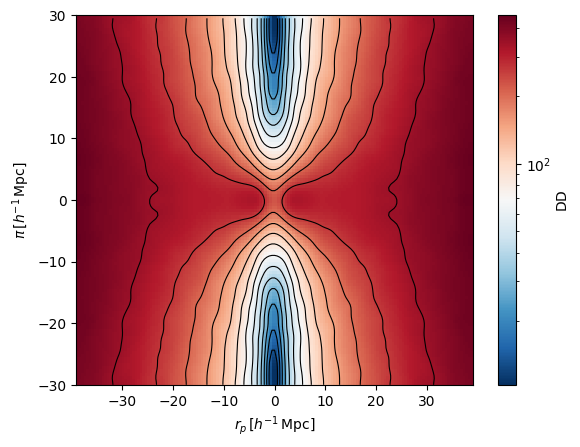

In [15]:
result2.plot2d(which="dd", contours=True, color_scale="log-positive", smoothing=2)